In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math
import numpy as np
import joblib
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV

import mlflow
import mlflow.sklearn


In [2]:
df = pd.read_csv('data/Loan_Data.csv')

In [3]:
df.head()

,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
0,8153374,0,5221.545193,3915.471226,78039.38546,5,605,0
1,7442532,5,1958.928726,8228.752520,26648.43525,2,572,1
2,2256073,0,3363.009259,2027.830850,65866.71246,4,602,0
3,4885975,0,4766.648001,2501.730397,74356.88347,5,612,0
4,4700614,1,1345.827718,1768.826187,23448.32631,6,631,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               10000 non-null  int64  
 1   credit_lines_outstanding  10000 non-null  int64  
 2   loan_amt_outstanding      10000 non-null  float64
 3   total_debt_outstanding    10000 non-null  float64
 4   income                    10000 non-null  float64
 5   years_employed            10000 non-null  int64  
 6   fico_score                10000 non-null  int64  
 7   default                   10000 non-null  int64  
dtypes: float64(3), int64(5)
memory usage: 625.1 KB


Aucune donnée nulle dans la df, et toutes les colonnes ont le même nombre de lignes. 

In [5]:
df.describe()

,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.974577e+06,1.461200,4159.677034,8718.916797,70039.901401,4.552800,637.557700,0.185100
std,2.293890e+06,1.743846,1421.399078,6627.164762,20072.214143,1.566862,60.657906,0.388398
min,1.000324e+06,0.000000,46.783973,31.652732,1000.000000,0.000000,408.000000,0.000000
25%,2.977661e+06,0.000000,3154.235371,4199.836020,56539.867903,3.000000,597.000000,0.000000
50%,4.989502e+06,1.000000,4052.377228,6732.407217,70085.826330,5.000000,638.000000,0.000000
75%,6.967210e+06,2.000000,5052.898103,11272.263740,83429.166133,6.000000,679.000000,0.000000
max,8.999789e+06,5.000000,10750.677810,43688.784100,148412.180500,10.000000,850.000000,1.000000


In [6]:
df.isnull().sum()

customer_id                 0
credit_lines_outstanding    0
loan_amt_outstanding        0
total_debt_outstanding      0
income                      0
years_employed              0
fico_score                  0
default                     0
dtype: int64

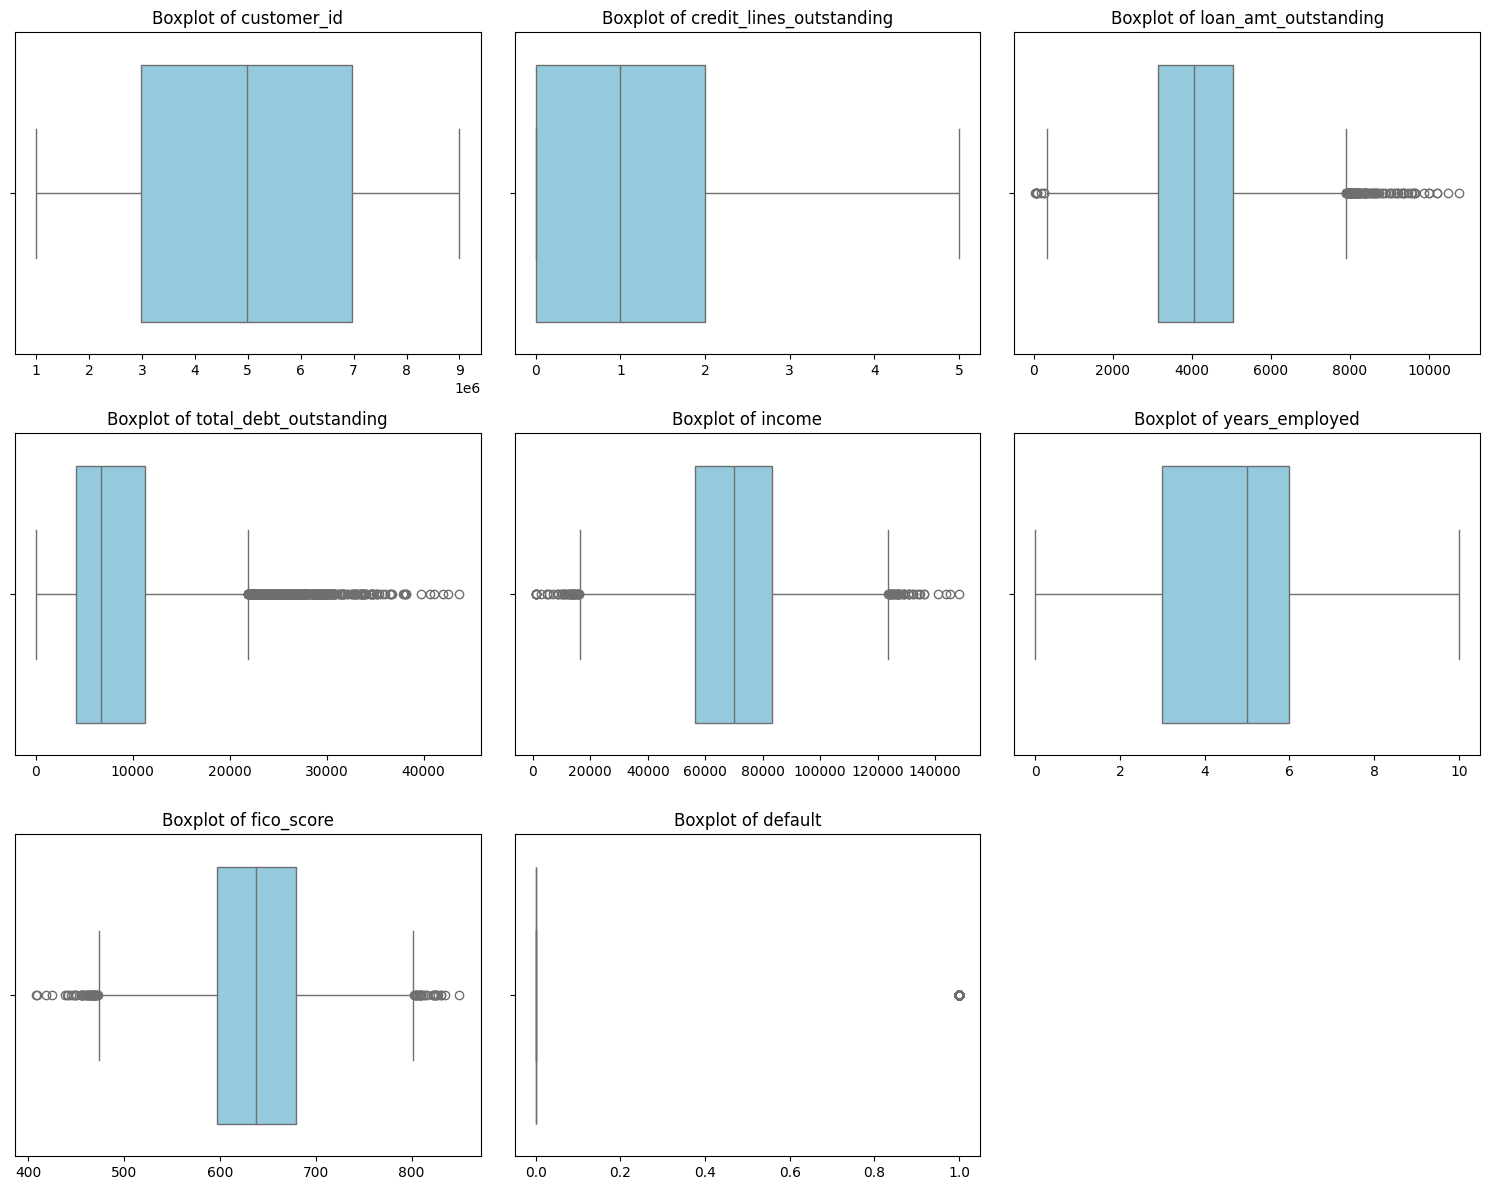

In [7]:
# 1. Sélection des colonnes numériques
numerical_features = df.select_dtypes(include=['number']).columns
n_features = len(numerical_features)

# 2. Configuration de la grille (ex: 3 colonnes)
n_cols = 3
n_rows = math.ceil(n_features / n_cols)

# 3. Création de la figure unique
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten() # On aplatit le tableau d'axes pour boucler facilement

for i, feature in enumerate(numerical_features):
    sns.boxplot(x=df[feature], ax=axes[i], color='skyblue')
    axes[i].set_title(f'Boxplot of {feature}')
    axes[i].set_xlabel('') # Optionnel : retire le label x pour plus de clarté

# 4. Supprimer les axes vides si le nombre de features n'est pas un multiple de n_cols
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Default : colonne de prédiction. Indique si client a fait défaut ou non sur son prêt. 

In [8]:
cols_to_log = ['total_debt_outstanding', 'loan_amt_outstanding']

Logs because data is skewed. 

In [9]:
for col in cols_to_log:
    df[col] = np.log1p(df[col])

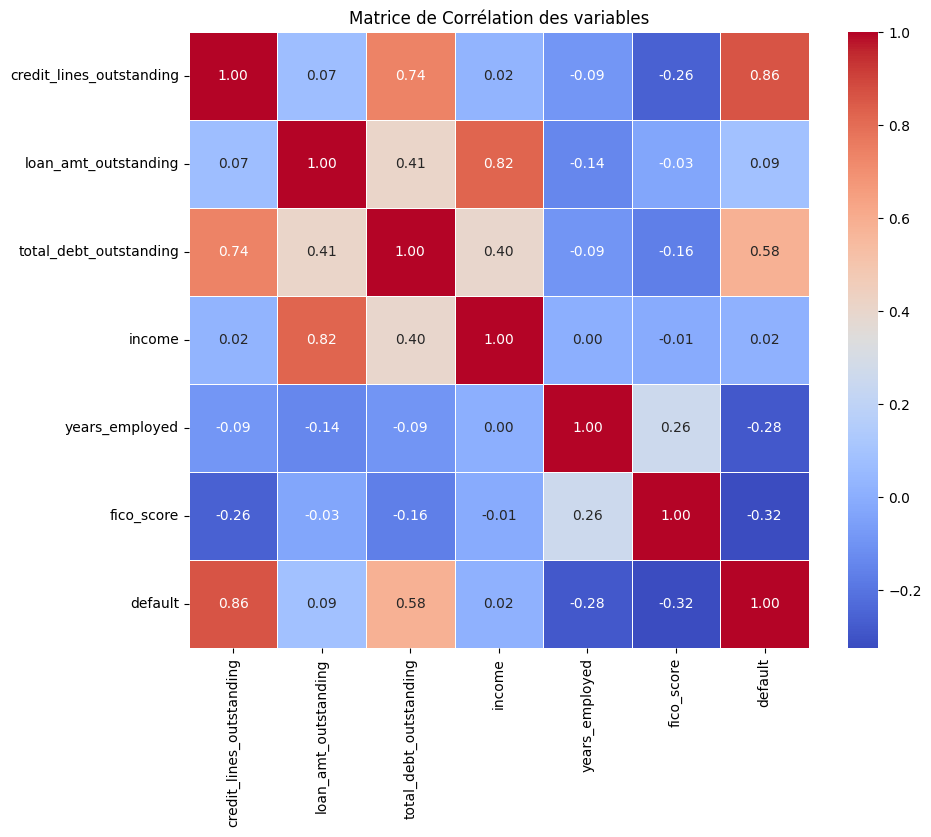

In [10]:
corr_matrix = df.drop(columns=['customer_id']).corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Matrice de Corrélation des variables")
plt.show()

# Train Test Split

In [11]:
y = df['default']

X = df.drop(columns=['default', 'customer_id'])

# Vérification rapide
print(f"Used features : {X.columns.tolist()}")

Used features : ['credit_lines_outstanding', 'loan_amt_outstanding', 'total_debt_outstanding', 'income', 'years_employed', 'fico_score']


In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [27]:
print(y_train.mean())
print(y_test.mean())

0.185125
0.185


In [13]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Classification

Définition des modèles

In [35]:
## Models definition 

#Logistic Regression
lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    C=0.01,  # commence avec une régularisation assez forte
    penalty='l2',
    solver='lbfgs'
)
lr.fit(X_train_scaled, y_train)

#Decision Tree
# 1. Définition des paramètres à tester
param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 10], # None = l'arbre pousse jusqu'au bout - overfitting
    'min_samples_split': [10, 20, 50],
    'min_samples_leaf': [10, 20, 50],
    'class_weight': ['balanced']
}

# 2. Configuration de la GridSearch
# On utilise cv=5 (Cross-Validation) pour être robuste
grid_search_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_dt,
    cv=5,
    scoring='roc_auc', # roc_auc pour dataset déséquilibré
    n_jobs=-1
)

# 3. Entraînement et évaluation
grid_search_dt.fit(X_train, y_train)
best_dt = grid_search_dt.best_estimator_

#Random Forest
# 1. Grille de paramètres pour la forêt
param_grid_rf = {
    'n_estimators': [100, 200],           # Nombre d'arbres dans la forêt
    'max_depth': [3, 5, 10],          # Profondeur de chaque arbre
    'min_samples_leaf': [10, 20, 50],        # Minimum d'échantillons par feuille
    'bootstrap': [True, False],
    'class_weight': ['balanced']            # Méthode de sélection des échantillons
}

# 2. Configuration GridSearch
grid_search_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

# 3. Entraînement et évaluation
grid_search_rf.fit(X_train, y_train)
best_dt = grid_search_rf.best_estimator_


c:\Users\alize\Documents\SDA_2025_2026\projet_mlops\creditloanprediction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [36]:
mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("credit-loan-prediction")

<Experiment: artifact_location='file:///c:/Users/alize/Documents/SDA_2025_2026/projet_mlops/creditloanprediction/mlruns/1', creation_time=1774797922153, experiment_id='1', last_update_time=1774797922153, lifecycle_stage='active', name='credit-loan-prediction', tags={}, workspace='default'>

In [40]:
from sklearn.metrics import classification_report, roc_auc_score

models = {
    "LogisticRegression": (lr, None),
    "DecisionTree_GridSearch": (grid_search_dt.best_estimator_, grid_search_dt.best_params_),
    "RandomForest": (grid_search_rf.best_estimator_, grid_search_rf.best_params_),
}

for model_name, (model, params) in models.items():
    with mlflow.start_run(run_name=model_name):
        
        y_pred = model.predict(X_test_scaled)
        probas = model.predict_proba(X_test_scaled)[:, 1]
        report = classification_report(y_test, y_pred, output_dict=True)

        # Logger les paramètres si disponibles (ex: GridSearch)
        if params:
            mlflow.log_params(params)

        mlflow.log_metric("accuracy",        report["accuracy"])
        mlflow.log_metric("f1_class_1",      report["1"]["f1-score"])
        mlflow.log_metric("recall_class_1",  report["1"]["recall"])
        mlflow.log_metric("precision_class_1", report["1"]["precision"])
        mlflow.log_metric("roc_auc",         roc_auc_score(y_test, probas))

        mlflow.sklearn.log_model(model, name=model_name)


2026/04/05 21:10:59 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
c:\Users\alize\Documents\SDA_2025_2026\projet_mlops\creditloanprediction\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\alize\Documents\SDA_2025_2026\projet_mlops\creditloanprediction\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
2026/04/05 21:11:04 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or c

In [44]:
runs = mlflow.search_runs(experiment_names=["credit-loan-prediction"])
runs_clean = runs.dropna(subset=["metrics.roc_auc"])
print(runs[[
    "tags.mlflow.runName",
    "metrics.roc_auc",
    "metrics.f1_class_1",
    "metrics.recall_class_1"
]].sort_values("metrics.roc_auc", ascending=False))

        tags.mlflow.runName  metrics.roc_auc  metrics.f1_class_1  \
3              RandomForest         0.499314            0.000000   
2        LogisticRegression         0.499314            0.275449   
4   DecisionTree_GridSearch         0.499314            0.304126   
5        LogisticRegression         0.499314            0.275449   
0              RandomForest         0.496455            0.000000   
1   DecisionTree_GridSearch         0.495697            0.304126   
6              RandomForest              NaN            0.000000   
7   DecisionTree_GridSearch              NaN            0.304126   
8        LogisticRegression              NaN            0.000000   
9              RandomForest              NaN            0.000000   
10  DecisionTree_GridSearch              NaN            0.304126   
11       LogisticRegression              NaN            0.000000   
12             RandomForest              NaN            0.804124   
13  DecisionTree_GridSearch              NaN    

In [31]:
# Trouver le meilleur run basé sur le f1_class_1
best_run = mlflow.search_runs(
    experiment_names=["credit-loan-prediction"],
    order_by=["metrics.f1_class_1 DESC"]
).iloc[0]

print(f"Meilleur modèle : {best_run['tags.mlflow.runName']}")
print(f"F1 score : {best_run['metrics.f1_class_1']:.4f}")
print(f"Accuracy : {best_run['metrics.accuracy']:.4f}")

# Enregistrer le meilleur modèle dans le Model Registry
best_run_id = best_run["run_id"]
model_name = best_run["tags.mlflow.runName"]

mlflow.register_model(
    model_uri=f"runs:/{best_run_id}/{model_name}",
    name="best_credit_loan_model"
)

print(f"Modèle '{model_name}' enregistré dans le Model Registry !")

Registered model 'best_credit_loan_model' already exists. Creating a new version of this model...
2026/04/05 20:49:01 WARNING mlflow.tracking._model_registry.fluent: Run with id 84bac5b73fe94c078e9198b8033f74a7 has no artifacts at artifact path 'LogisticRegression', registering model based on models:/m-6694b9d9dfbf44e8803a111d8f060058 instead


Meilleur modèle : LogisticRegression
F1 score : 0.9812
Accuracy : 0.9935
Modèle 'LogisticRegression' enregistré dans le Model Registry !


Created version '3' of model 'best_credit_loan_model'.


In [32]:
model = mlflow.sklearn.load_model("models:/best_credit_loan_model/1")
probas = model.predict_proba(X_test_scaled)[:, 1]
print(probas[:20])

[2.40467595e-07 4.69313061e-03 9.99991592e-01 5.71028084e-11
 2.44946521e-08 3.44651901e-11 5.32212027e-08 6.00120657e-08
 9.98774723e-01 2.60703219e-08 9.99861798e-01 9.58757250e-09
 3.95647856e-03 9.99987319e-01 1.64563665e-08 9.99586302e-01
 8.40453819e-09 1.64917932e-09 9.99996897e-01 1.32356406e-08]


**1 - Logistic Regression**

In [19]:
#Training Logistic Regression
log_reg = LogisticRegression()
log_reg.fit(X_train_scaled, y_train)
y_pred_log = log_reg.predict(X_test_scaled)


print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_log))

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1652
           1       0.99      0.98      0.98       348

    accuracy                           0.99      2000
   macro avg       0.99      0.99      0.99      2000
weighted avg       0.99      0.99      0.99      2000



In [34]:
lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    C=0.01,  # commence avec une régularisation assez forte
    penalty='l2',
    solver='lbfgs'
)

lr.fit(X_train_scaled, y_train)

# Évaluation
y_pred = lr.predict(X_test_scaled)
probas = lr.predict_proba(X_test_scaled)[:, 1]
print(probas[:20])
print(classification_report(y_test, y_pred))

[0.50398771 0.4858234  0.47047404 0.53225446 0.49670682 0.52621361
 0.49121692 0.49884414 0.48306372 0.49578597 0.49516903 0.5085856
 0.48008276 0.47046251 0.50583343 0.5017053  0.49329787 0.51931416
 0.47426681 0.49880695]
              precision    recall  f1-score   support

           0       0.82      0.52      0.64      1630
           1       0.19      0.50      0.28       370

    accuracy                           0.52      2000
   macro avg       0.51      0.51      0.46      2000
weighted avg       0.70      0.52      0.57      2000



c:\Users\alize\Documents\SDA_2025_2026\projet_mlops\creditloanprediction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [20]:
importance = pd.DataFrame({'Feature': X.columns, 'Coefficient': log_reg.coef_[0]})
print(importance.sort_values(by='Coefficient', ascending=False))

                    Feature  Coefficient
0  credit_lines_outstanding     9.775171
2    total_debt_outstanding     2.132739
3                    income    -0.425708
1      loan_amt_outstanding    -0.428390
5                fico_score    -1.078419
4            years_employed    -2.999087


# Decision Tree

In [21]:
# 1. Définition des paramètres à tester
param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 10, None], # None = l'arbre pousse jusqu'au bout
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# 2. Configuration de la GridSearch
# On utilise cv=5 (Cross-Validation) pour être robuste
grid_search_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_dt,
    cv=5,
    scoring='f1', # On optimise le F1-score car le défaut est une classe sensible
    n_jobs=-1
)

# 3. Entraînement
grid_search_dt.fit(X_train, y_train)

# 4. Affichage des meilleurs paramètres
print("Meilleurs paramètres Arbre :", grid_search_dt.best_params_)

# 5. Évaluation du meilleur modèle
best_dt = grid_search_dt.best_estimator_
y_pred_best_dt = best_dt.predict(X_test)

print("\nReport de l'Arbre Optimisé :")
print(classification_report(y_test, y_pred_best_dt))

Meilleurs paramètres Arbre : {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2}

Report de l'Arbre Optimisé :
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1652
           1       0.99      0.98      0.99       348

    accuracy                           1.00      2000
   macro avg       0.99      0.99      0.99      2000
weighted avg       1.00      1.00      1.00      2000



# Random Forest

In [22]:
# 1. Grille de paramètres pour la forêt
param_grid_rf = {
    'n_estimators': [100, 200],           # Nombre d'arbres dans la forêt
    'max_depth': [10, 20, None],          # Profondeur de chaque arbre
    'min_samples_leaf': [1, 2, 4],        # Minimum d'échantillons par feuille
    'bootstrap': [True, False]            # Méthode de sélection des échantillons
}

# 2. Configuration GridSearch
grid_search_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

# 3. Entraînement
grid_search_rf.fit(X_train, y_train)

# 4. Résultats
print("Meilleurs paramètres Random Forest :", grid_search_rf.best_params_)

# 5. Évaluation finale
best_rf = grid_search_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test)

print("\nReport du Random Forest Optimisé :")
print(classification_report(y_test, y_pred_rf))

Meilleurs paramètres Random Forest : {'bootstrap': False, 'max_depth': 20, 'min_samples_leaf': 1, 'n_estimators': 200}

Report du Random Forest Optimisé :
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1652
           1       0.99      0.98      0.99       348

    accuracy                           0.99      2000
   macro avg       0.99      0.99      0.99      2000
weighted avg       0.99      0.99      0.99      2000



In [23]:
# Récupérer l'importance des variables du Random Forest
rf_importances = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values(ascending=False)

# Récupérer les coefficients de la Régression Logistique (en valeur absolue pour comparer l'impact)
log_importances = pd.Series(abs(log_reg.coef_[0]), index=X.columns).sort_values(ascending=False)

print("TOP FEATURES - Random Forest:\n", rf_importances)
print("\nTOP FEATURES - LogReg:\n", log_importances)

TOP FEATURES - Random Forest:
 credit_lines_outstanding    0.582897
total_debt_outstanding      0.284443
years_employed              0.053018
fico_score                  0.041393
income                      0.026527
loan_amt_outstanding        0.011722
dtype: float64

TOP FEATURES - LogReg:
 credit_lines_outstanding    9.775171
years_employed              2.999087
total_debt_outstanding      2.132739
fico_score                  1.078419
loan_amt_outstanding        0.428390
income                      0.425708
dtype: float64


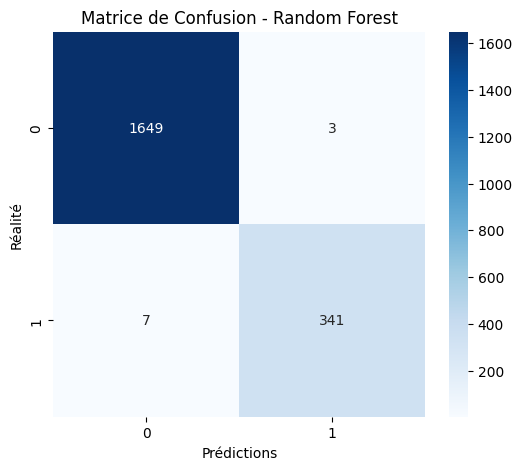

In [24]:
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Prédictions')
plt.ylabel('Réalité')
plt.title('Matrice de Confusion - Random Forest')
plt.show()

In [25]:
# Save the Random Forest model
os.makedirs('models', exist_ok=True)  
joblib.dump(best_rf, 'models/credit_risk_model_rf.pkl')

# Save the scaler (in case you need it for LogReg later)
joblib.dump(scaler, 'models/scaler_credit.pkl')

print("Models saved successfully!")

Models saved successfully!
